Functions needed to precondition CG with preconditioner as described in "Fast Iteratively Reweighted Least Squares Algorithms for Analysis-Based Sparsity Reconstruction"


Function that creates a, b, c as in Figure (41)
Function that solves lower triangular system with input the diagonals
Function that solves upper triangular system with input the diagonals

In [11]:
# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.algorithms import FISTA

from cil.plugins.ccpi_regularisation.functions import FGP_TV

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared, IndicatorBox
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator, MaskOperator

In [12]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss


Computing $\overline{A^TA}$

In [13]:
def mean_ATA(A, n_pixels):
    """
    A is a ProjectionOperator
    """
    two_norm = L2NormSquared()
    get_ig = A.domain_geometry()

    sum = 0
    for k in range(3):

        # generate random entries
        xk = np.random.normal(0, 1, (n_pixels, n_pixels))

        # put random entries in class <DataContainer>
        xk_datacon = get_ig.allocate()
        xk_datacon.fill(xk)

        # compute 
        yk = A.direct(xk_datacon)
        sum += two_norm(yk)
    
    final = (1/3)*sum
    return final

## Preconditioning the TV norm

Solving LU

In [14]:
def create_abs(A, weights, n, ATAI_mean, alpha):
    """
    Creates the entries of the matrix in figure (41) in the article 'Fast Iteratively Reweighted Least Squares
    Algorithms for Analysis-Based Sparsity Reconstruction'

    INPUT
        n: number of pixels (n_pixels)
        A: ProjectionOperator
        weights: weights in np.array(), not flattened

    OUTPUT
        a: diagonal elements of figure (41)
        b: lower- and upperdiagonal elements of figure (41)
        c: offdiagonal elements of figure (41)
    """

    weights_arr = weights.as_array()

    # creating diagonal elements
    a_1 = weights_arr.flatten()
    a_2 = weights_arr.flatten()

    pix_squared = len(a_1)
    for i in range(pix_squared - 1):
        a_1[i] += a_1[i+1]

    for i in range(pix_squared - n):
        a_2[i] += a_2[i + n]

    #a = alpha*(a_1 + a_2) + ATAI_mean
    a = a_1 + a_2 + ATAI_mean

    # creating lower-, upper-, and offdiagonal elements
    b = (-weights_arr.flatten())[1:]
    c = (-weights_arr.flatten())[n:]
    
    # b *= alpha
    # c *= alpha

    return a, b, c

def solve_Ux(diag, updiag, offdiag, y):
    """

    Solves Ux = y, if the matrix U is upper triangular and 
    has the form as in figure (43)
    
    INPUT:
        diag: diagonal elements of U (np.array())
        updiag: upper diagonal elements of U (np.array())
        offdiag: off diagonal elements of U (np.array())
        y: known vector (np.array())

    OUTPUT:
        x: solution to Ux = y (np.array())

    """

    # relation between N and n is given in the article
    N_big = len(diag)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[-1] = y[-1] / diag[-1]    

    # loop over entries of x, first element last
    for i in range(2, N_big + 1):   
        k = N_big - i
        
        # if statements since only part of the entries of x are affected by offdiagonal entries
        if k >= N_big - n:   
            #print("first if", N_big - i)
            x[k] = (1 / diag[k]) * (y[k] - updiag[k]*x[k + 1])
        if k < N_big - n:
            #print("second if", N_big - i)
            x[k] = (1 / diag[k]) * (y[k] - updiag[k]*x[k + 1] - offdiag[k] * x[k + n])

    return x

def solve_Lx(lowdiag, offdiag, y):

    """ 
    solves Lx = y, with L lower triangular and in the from of figure (42)

    INPUT:
        lowdiag: lower diagonal entries (np.array())
        offdiag: offdiagonal entries (np.array())
        y: known vector (np.array())

    OUTPUT:
        x: solution to Lx = y (np.array())
    """
    
    # relation between N and n is given in the article
    N_big = len(y)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[0] = y[0]

    # loop over the entries of x
    for i in range(1, N_big):

        # if statements, since the offdiagonal entries only influence part of x
        if i < n:
            x[i] = y[i] - lowdiag[i - 1]*x[i - 1]
        if i >= n:
            x[i] = y[i] - lowdiag[i - 1]*x[i - 1] - offdiag[i - n]*x[i - n]

    return x

def solve_Pxy(P_a, P_b, P_c, y):
    
    """
    solves Px = y, with P the matrix as in figure (41) of the article 
    'Fast Iteratively Reweighted Least Squares Algorithms for Analysis-Based 
    Sparsity Reconstruction'. P has an known incomplete LU decomposition. 

    INPUT:
        P_a: diagonal elements of the matrix in figure (41) (np.array())
        P_b: lower- and upperdiagonal elements of the matrix in figure (41) (np.array())
        P_c: offdiagonal elements of the matrix in figure (41) (np.array())
        y: known in Px = y (ImageData)
    
    OUTPUT:
        x: solution of Px = y (ImageData) 
        NOTE: is currently NOT ImageData, but an np.array()
    """

    L_lowdiag = P_b / P_a[:-1]
    L_offdiag = P_c / P_a[:len(P_c)]

    sol = y.copy()
    
    y_arr = y.as_array()
    n = len(y_arr)
    y_flat = y_arr.flatten()

    temp_solve = solve_Lx(L_lowdiag, L_offdiag, y_flat)
    x = solve_Ux(P_a, P_b, P_c, temp_solve)
    
    x_reshape = np.reshape(x, (n, n))
    sol.fill(x_reshape)

    return sol

CG functions

In [15]:
def apply_operator_tv(x, W, A, alpha):
    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        A:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final

def CG_tv(initial, max_iter, A, b, alpha, Wk, CG_tol):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = b - apply_operator_tv(x=u0, W=Wk, A=A, alpha=alpha)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = CG_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator_tv(x=pk, W=Wk, A=A, alpha=alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        conv_arr.append(check)
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr

def CG_tv_preconditioned(initial, max_iter, A, b, alpha, Wk, cg_tol, ATAI_mean):
    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    preconditioned

    """

    u0 = initial.copy()
    r0 = b - apply_operator_tv(u0, Wk, A, alpha)

    n_pixels = int(np.sqrt(np.size(u0)))
    P_a, P_b, P_c = create_abs(A, Wk, n_pixels, ATAI_mean, alpha)
    w0 = solve_Pxy(P_a, P_b, P_c, r0)
    p0 = w0

    # set initials, note these are all of class <ImageData>
    wk = w0
    pk = p0
    uk = u0
    rk = r0

    delta_new = rk.dot(wk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # perform CG iterations
    for k in range(max_iter):

        zk = apply_operator_tv(pk, Wk, A, alpha)

        alpha_k = delta_new / (pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        P_a, P_b, P_c = create_abs(A, Wk, n_pixels, ATAI_mean, alpha)
        wk_plus_one = solve_Pxy(P_a, P_b, P_c, rk_plus_one)
        delta_new = wk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new / delta_old

        pk_plus_one = wk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  
        conv_arr.append(check)
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k + 1} iterations")
            break

        # reset variables
        rk = rk_plus_one 
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr

Final solver

In [16]:
def tv_solver_normal(initial, inner_iter, outer_iter, A, sino, alpha, er, pre, cg_tol):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        pre:        Determine to put in preconditioner (Boolean)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """
    uk = initial.copy()
    n_pixels = int(np.sqrt(np.size(uk)))

    if pre == "True":
        ATAI_mean = mean_ATA(A, n_pixels)

    # create lhs, A^Tb
    lhs = A.adjoint(sino)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        if pre == "True":
            cg_output, conv_arr = CG_tv_preconditioned(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, ATAI_mean)
        else:
            cg_output, conv_arr = CG_tv(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol)
    
        uk = cg_output

        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr


Run results

In [17]:
test = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])

test_reshape = np.reshape(test, (3, 3), 'F')
print(test_reshape)

[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [18]:
A, sino, ig, ag, phantom = get_A(50, 265)
sino_noisy = add_poss_noise(20000, 50, 265)

uk = ig.allocate(0)
import time

t2_start = time.time()
sol2, err2, conv_arr2 = tv_solver_normal(initial = ig.allocate(0), 
                       inner_iter = 100, 
                       outer_iter = 3, 
                       A = A,
                       sino = sino_noisy, 
                       alpha = 1e-6, 
                       er = None, 
                       pre = "False", 
                       cg_tol = 1e-2)
t2_end = time.time()

t1_start = time.time()
sol, err, conv_arr = tv_solver_normal(initial = ig.allocate(0), 
                       inner_iter = 100, 
                       outer_iter = 3, 
                       A = A,
                       sino = sino_noisy, 
                       alpha = 1e-6, 
                       er = None, 
                       pre = "True", 
                       cg_tol = 1e-2)
t1_end = time.time()


print("time with preconditioning", t1_end - t1_start)
print("time without preconditioning", t2_end - t2_start)

outer iteration: 1


c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


cg converged in 2 iterations
outer iteration: 2
cg converged in 58 iterations
outer iteration: 3
cg converged in 97 iterations
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 43 iterations
outer iteration: 3
cg converged in 63 iterations
time with preconditioning 65.91179132461548
time without preconditioning 12.014192342758179


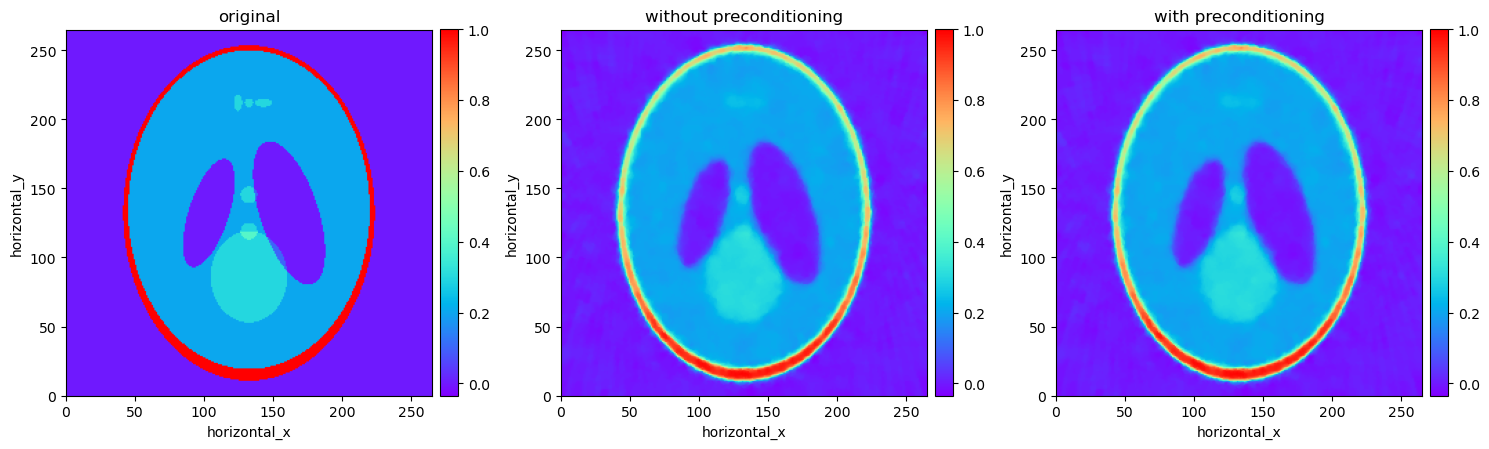

In [19]:
show2D([phantom, sol2, sol], ['original', 'without preconditioning', 'with preconditioning'], num_cols = 3, cmap="rainbow", fix_range=True)

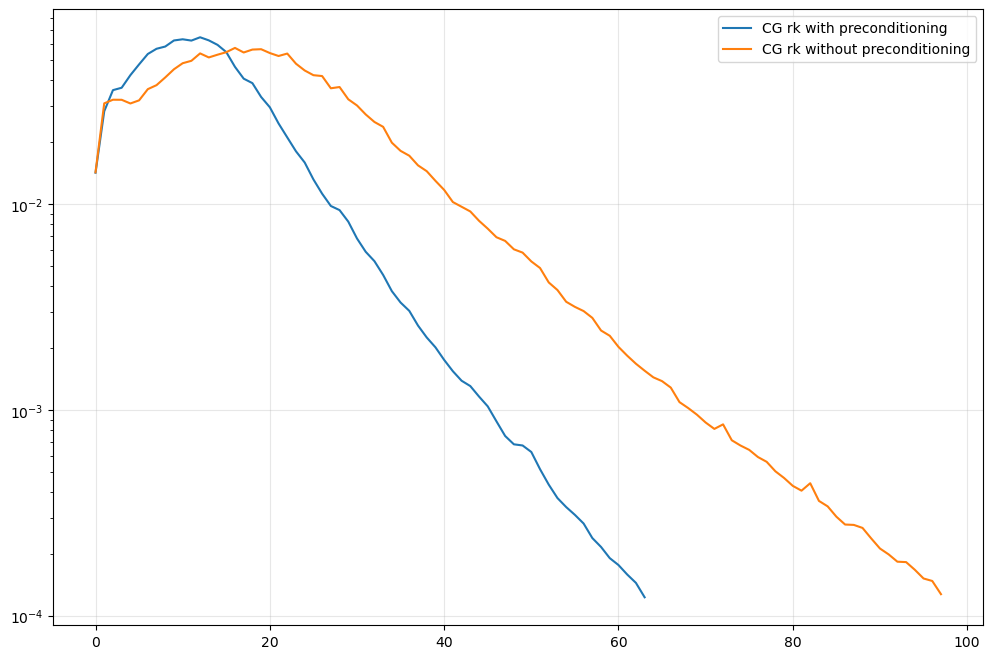

In [20]:
plt.figure(figsize=(12, 8))
plt.semilogy(conv_arr, label='CG rk with preconditioning')
plt.semilogy(conv_arr2, label='CG rk without preconditioning')
plt.legend()
plt.grid(alpha = 0.3)